In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

# Download all three stocks at once
tickers = ['NUAI', 'EOSE', 'FLNC']

data = yf.download(tickers, start='2022-01-01', end='2026-07-28')

print(data.shape)
print(data.head())

[*********************100%***********************]  3 of 3 completed

(1144, 15)
Price      Close                   High                    Low             \
Ticker      EOSE       FLNC  NUAI  EOSE       FLNC  NUAI  EOSE       FLNC   
Date                                                                        
2022-01-03  7.60  34.869999   NaN  7.92  36.705002   NaN  7.42  34.570000   
2022-01-04  7.06  34.849998   NaN  7.61  35.810001   NaN  6.84  34.270000   
2022-01-05  6.87  30.230000   NaN  7.12  35.070000   NaN  6.86  29.575001   
2022-01-06  6.58  28.059999  9.83  6.82  30.430000  9.83  6.36  27.650000   
2022-01-07  6.51  27.400000  9.80  6.72  28.670000  9.81  6.37  27.200001   

Price             Open                   Volume                    
Ticker      NUAI  EOSE       FLNC  NUAI    EOSE     FLNC     NUAI  
Date                                                               
2022-01-03   NaN  7.58  35.910000   NaN  412800   583600      NaN  
2022-01-04   NaN  7.61  35.290001   NaN  844000   589000      NaN  
2022-01-05   NaN  7.11  34.75999

In [3]:
close_prices = data['Close']
print(close_prices.head())
print(close_prices.shape)

Ticker      EOSE       FLNC  NUAI
Date                             
2022-01-03  7.60  34.869999   NaN
2022-01-04  7.06  34.849998   NaN
2022-01-05  6.87  30.230000   NaN
2022-01-06  6.58  28.059999  9.83
2022-01-07  6.51  27.400000  9.80
(1144, 3)


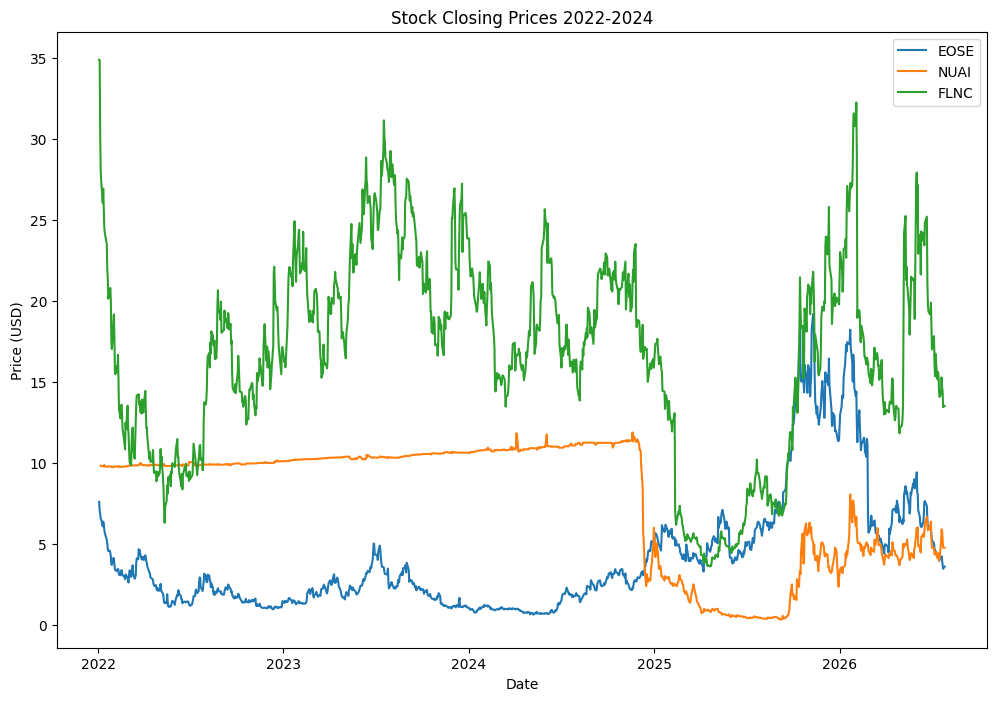

In [4]:
plt.figure(figsize=(12, 8))
plt.plot(close_prices.index, close_prices['EOSE'], label='EOSE')
plt.plot(close_prices.index, close_prices['NUAI'], label='NUAI')
plt.plot(close_prices.index, close_prices['FLNC'], label='FLNC')

plt.title("Stock Closing Prices 2022-2024")
plt.xlabel("Date")
plt.ylabel("Price (USD)")

plt.legend()
plt.show()

## Observation
NUAI showed unusual price stability ($10-11) for 2+ years before a sharp 
decline in late 2024. FLNC experienced a classic post-IPO correction from 
$35 to $10. EOSE remained depressed before showing recent momentum.
Further fundamental research needed to explain specific price movements.

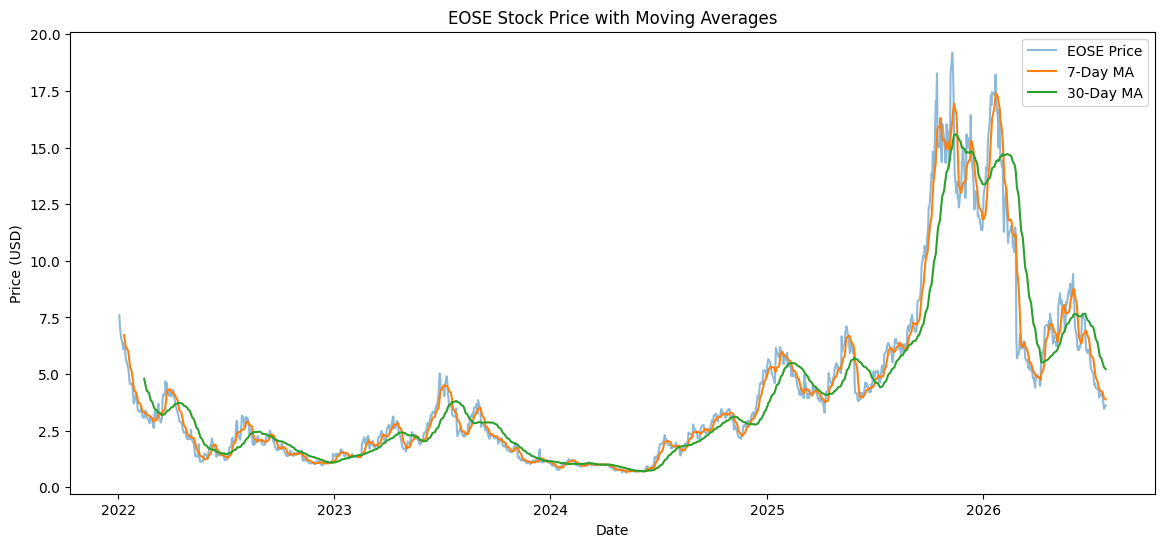

In [5]:
eose_7ma = close_prices['EOSE'].rolling(window=7).mean()
eose_30ma = close_prices['EOSE'].rolling(window=30).mean()

# Step 2 - Plot all three lines on the same chart
plt.figure(figsize=(14, 6))
plt.plot(close_prices.index, close_prices['EOSE'], label='EOSE Price', alpha=0.5)
plt.plot(close_prices.index, eose_7ma, label='7-Day MA')
plt.plot(close_prices.index, eose_30ma, label='30-Day MA')

plt.title('EOSE Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## EOSE Moving Average Analysis
7-day and 30-day moving averages reveal EOSE bottomed around mid-2024 
at ~$0.90 before entering a powerful bullish uptrend. The 7-day MA 
crossing above the 30-day MA in late 2024 confirmed the breakout, 
with price ultimately reaching $19 by early 2026 — a 2,000%+ gain 
from the bottom. Both MAs are now trending downward, suggesting the 
spike has peaked and a consolidation phase has begun.

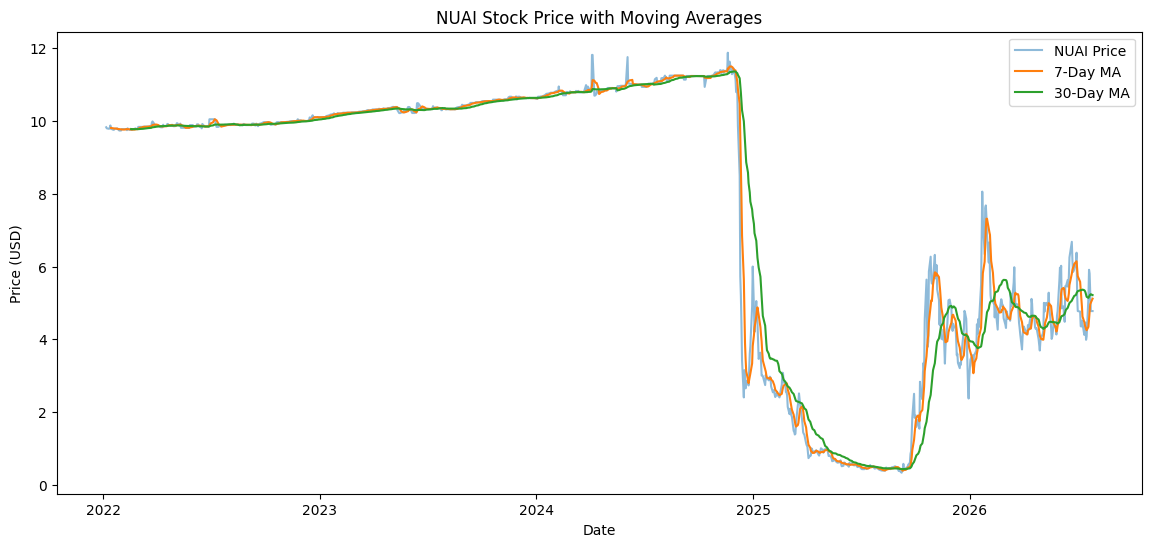

In [6]:
nuai_7ma = close_prices['NUAI'].rolling(window=7).mean()
nuai_30ma = close_prices['NUAI'].rolling(window=30).mean()

# Step 2 - Plot all three lines on the same chart
plt.figure(figsize=(14, 6))
plt.plot(close_prices.index, close_prices['NUAI'], label='NUAI Price', alpha=0.5)
plt.plot(close_prices.index, nuai_7ma, label='7-Day MA')
plt.plot(close_prices.index, nuai_30ma, label='30-Day MA')

plt.title('NUAI Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## NUAI Moving Average Analysis
NUAI showed extraordinary price stability ($10-11) for nearly 3 years,
with 7-day and 30-day MAs virtually identical — suggesting extremely
low volatility and thin trading volume. The sudden collapse in late 2024
saw both MAs drop sharply, confirming a sustained downtrend rather
than a temporary dip. The switch from helium to energy in 2025 caused the stock to shoot up and down all throughout late 2025 into 2026

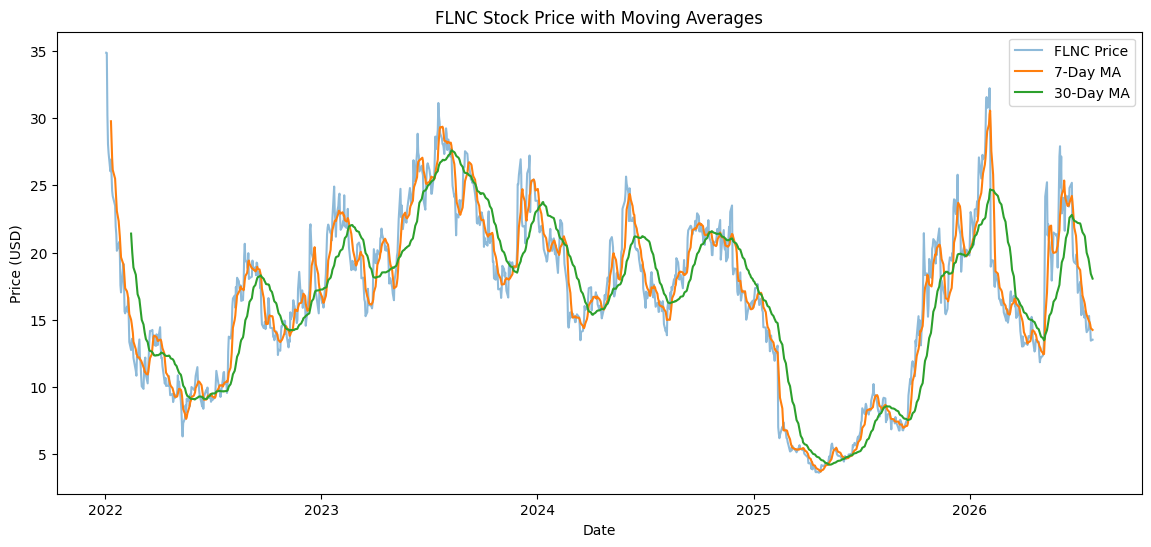

In [7]:
flnc_7ma = close_prices['FLNC'].rolling(window=7).mean()
flnc_30ma = close_prices['FLNC'].rolling(window=30).mean()

# Step 2 - Plot all three lines on the same chart
plt.figure(figsize=(14, 6))
plt.plot(close_prices.index, close_prices['FLNC'], label='FLNC Price', alpha=0.5)
plt.plot(close_prices.index, flnc_7ma, label='7-Day MA')
plt.plot(close_prices.index, flnc_30ma, label='30-Day MA')

plt.title('FLNC Stock Price with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## FLNC Moving Average Analysis
FLNC shows classic cyclical behavior with clear boom/bust patterns.
Post-IPO crash from $35 to $6 in early 2022, followed by a strong
recovery to $30 by mid-2023. Multiple 7-day/30-day MA crossovers
visible as tradeable signals. The stock shot up throughout late 2025 to early 2026 from around $4 to $33. The stock is currently in the $11 range.

In [8]:
daily_returns = close_prices.pct_change()
print(daily_returns.head(10))

Ticker          EOSE      FLNC      NUAI
Date                                    
2022-01-03       NaN       NaN       NaN
2022-01-04 -0.071053 -0.000574       NaN
2022-01-05 -0.026912 -0.132568       NaN
2022-01-06 -0.042213 -0.071783       NaN
2022-01-07 -0.010638 -0.023521 -0.003052
2022-01-10 -0.064516 -0.049270 -0.001020
2022-01-11  0.047619  0.033397  0.000000
2022-01-12 -0.020376 -0.040862  0.001021
2022-01-13 -0.054400 -0.047250  0.008163
2022-01-14 -0.037225 -0.016260 -0.009109


In [9]:
volatility = daily_returns.std()
print(volatility.sort_values(ascending=False))

Ticker
EOSE    0.076412
NUAI    0.072645
FLNC    0.062704
dtype: float64


## Volatility Analysis
EOSE is the most volatile stock (7.6% daily std dev) despite having 
the lowest absolute price — percentage moves matter more than dollar moves.
FLNC is the least volatile (6.2%).

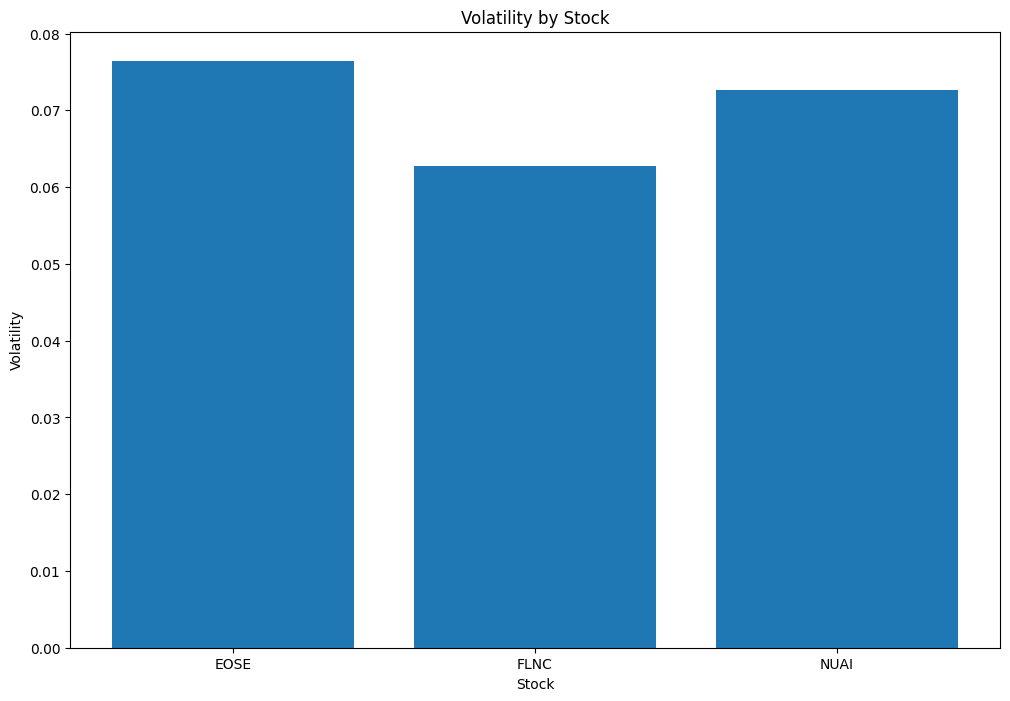

In [10]:
plt.figure(figsize=(12,8))

plt.bar(volatility.index, volatility.values)
plt.title("Volatility by Stock")
plt.xlabel("Stock")
plt.ylabel("Volatility")
plt.show()

## Disclaimer
Stock price forecasting is inherently uncertain. Prophet forecasts 
are based on historical patterns only and do not account for future 
news, earnings, or market events. This is for educational purposes 
only and not financial advice.

In [11]:
from prophet import Prophet

nuai_prophet = close_prices['NUAI'].reset_index()
nuai_prophet.columns = ['ds', 'y']

nuai_prophet = nuai_prophet.dropna()

print(nuai_prophet.head())
print(nuai_prophet.shape)

c:\Users\08300\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


          ds     y
3 2022-01-06  9.83
4 2022-01-07  9.80
5 2022-01-10  9.79
6 2022-01-11  9.79
7 2022-01-12  9.80
(1141, 2)


In [12]:
model = Prophet(daily_seasonality=False, weekly_seasonality=False)
model.fit(nuai_prophet)

future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

17:23:53 - cmdstanpy - INFO - Chain [1] start processing
17:23:54 - cmdstanpy - INFO - Chain [1] done processing


             ds      yhat  yhat_lower  yhat_upper
1311 2027-01-14  8.849304    7.134407   10.397588
1312 2027-01-15  8.896083    7.145091   10.416771
1313 2027-01-16  8.938737    7.004152   10.585531
1314 2027-01-17  8.977280    7.251111   10.551115
1315 2027-01-18  9.011796    7.108130   10.559810
1316 2027-01-19  9.042431    7.255138   10.751195
1317 2027-01-20  9.069387    7.200561   10.605485
1318 2027-01-21  9.092907    7.298290   10.823410
1319 2027-01-22  9.113266    7.248458   10.699452
1320 2027-01-23  9.130764    7.316624   10.817579


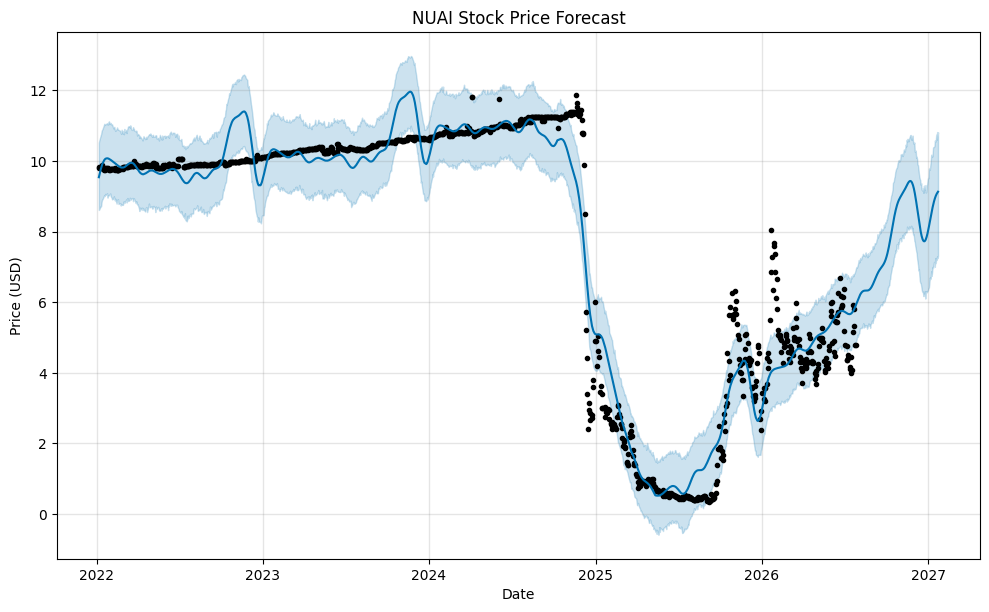

In [13]:
fig1 = model.plot(forecast)
plt.title('NUAI Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

## NUAI Prophet Forecast
Prophet successfully modeled NUAI's unusual flat period and dramatic 
late-2024 crash. The model predicts a continued recovery toward $9-10 
by early 2027, though the widening confidence interval reflects 
increasing uncertainty. Note: NUAI's business pivot from helium to 
energy may affect the validity of pattern-based forecasts.

In [14]:
eose_prophet = close_prices['EOSE'].reset_index()
eose_prophet.columns = ['ds', 'y']

eose_prophet = eose_prophet.dropna()

print(eose_prophet.head())
print(eose_prophet.shape)

          ds     y
0 2022-01-03  7.60
1 2022-01-04  7.06
2 2022-01-05  6.87
3 2022-01-06  6.58
4 2022-01-07  6.51
(1144, 2)


In [15]:
model = Prophet(daily_seasonality=False, weekly_seasonality=False)
model.fit(eose_prophet)

future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

17:33:26 - cmdstanpy - INFO - Chain [1] start processing
17:33:27 - cmdstanpy - INFO - Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
1314 2027-01-14  10.156222    7.667557   12.559750
1315 2027-01-15  10.181505    7.661290   12.751775
1316 2027-01-16  10.198310    7.695294   12.756494
1317 2027-01-17  10.206150    7.640646   12.695489
1318 2027-01-18  10.204671    7.717375   12.866142
1319 2027-01-19  10.193663    7.811340   12.600367
1320 2027-01-20  10.173061    7.754399   12.588770
1321 2027-01-21  10.142948    7.597288   12.665083
1322 2027-01-22  10.103552    7.627149   12.414711
1323 2027-01-23  10.055237    7.598680   12.454421


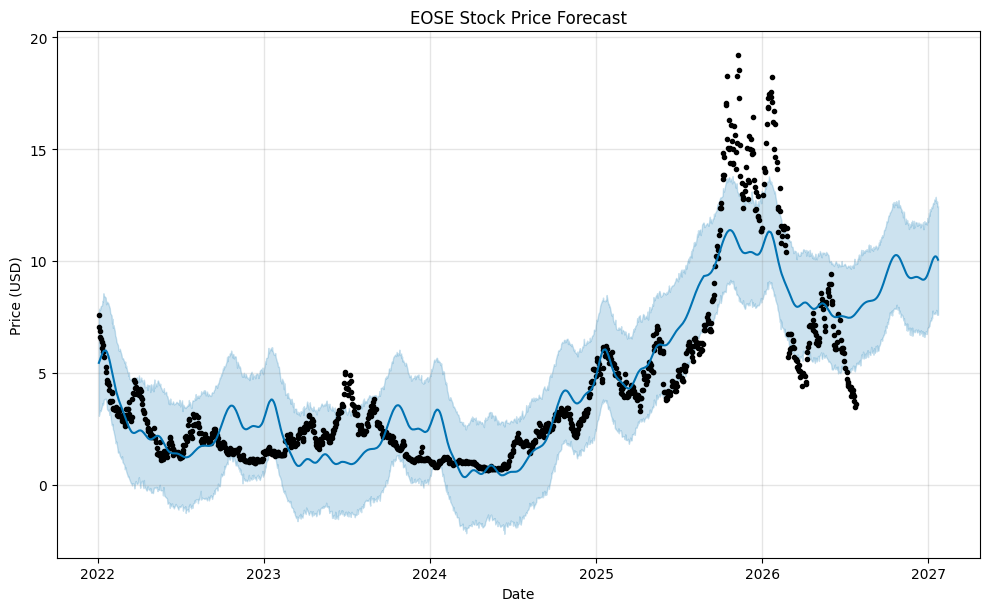

In [16]:
fig2 = model.plot(forecast)
plt.title('EOSE Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

## EOSE Prophet Forecast
Prophet successfully modeled EOSE's slow 2022-2024 uptrend but seemed to
highly underestimated the 2025-2026 spike to $19-20, which is
likely driven by a fundamental catalyst Prophet couldn't anticipate.
Current prices are reverting toward Prophet's predicted trend line,
suggesting the large spike was temporary. Model forecasts ~$10 by 2027.

In [17]:
flnc_prophet = close_prices['FLNC'].reset_index()
flnc_prophet.columns = ['ds', 'y']

flnc_profit = flnc_prophet.dropna()

print(flnc_prophet.head())
print(flnc_prophet.shape)

          ds          y
0 2022-01-03  34.869999
1 2022-01-04  34.849998
2 2022-01-05  30.230000
3 2022-01-06  28.059999
4 2022-01-07  27.400000
(1144, 2)


In [18]:
model = Prophet(daily_seasonality=False, weekly_seasonality=False)
model.fit(flnc_prophet)

future = model.make_future_dataframe(periods=180)

forecast = model.predict(future)

print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(10))

17:42:16 - cmdstanpy - INFO - Chain [1] start processing
17:42:17 - cmdstanpy - INFO - Chain [1] done processing


             ds       yhat  yhat_lower  yhat_upper
1314 2027-01-14  34.223049   29.877521   39.055304
1315 2027-01-15  34.320438   29.473331   39.168898
1316 2027-01-16  34.406655   29.805517   39.261887
1317 2027-01-17  34.480176   29.930046   39.331048
1318 2027-01-18  34.539565   29.798900   39.502133
1319 2027-01-19  34.583501   29.944019   39.303905
1320 2027-01-20  34.610795   30.138700   39.229291
1321 2027-01-21  34.620415   29.594763   39.287866
1322 2027-01-22  34.611497   30.105355   39.554082
1323 2027-01-23  34.583365   30.041603   39.061162


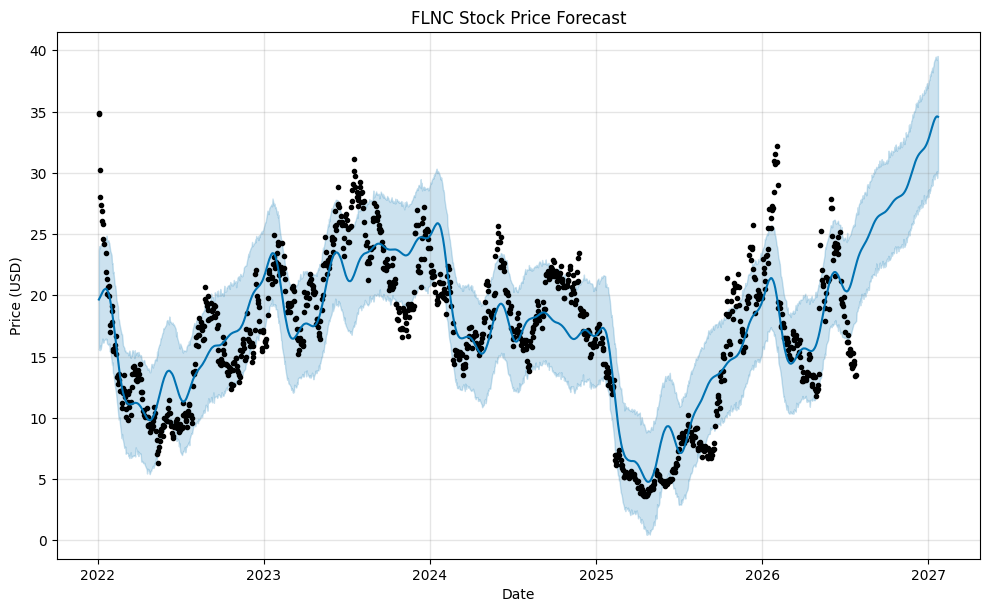

In [19]:
fig3 = model.plot(forecast)
plt.title('FLNC Stock Price Forecast')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.show()

## FLNC Prophet Forecast
FLNC's cyclical price behavior makes it the most forecastable of the 
three stocks. Prophet successfully tracked multiple boom/bust cycles.
After bottoming at ~$4 in early 2025, the model predicts a strong 
recovery toward $35-40 by 2027 — near original IPO prices.
Wide confidence intervals reflect the stock's high volatility (5.5% 
daily std dev).